# UR5e Robot Playing Chinese Chess (Xiangqi)
Simulation of a UR5e robot arm moving chess pieces on a Xiangqi board using inverse kinematics control.

In [30]:
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import mediapy as media
import numpy as np

## Load the Model

In [31]:
xml_path = "universal_robots_ur5e/scene_xiangqi.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

## Initial Scene Visualization

""

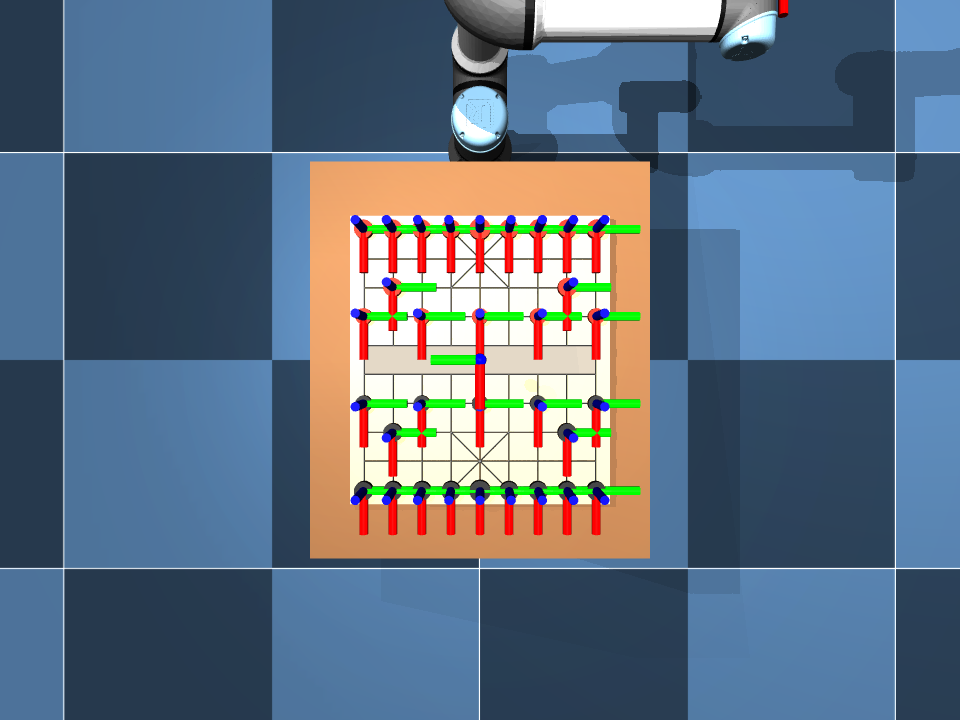

""

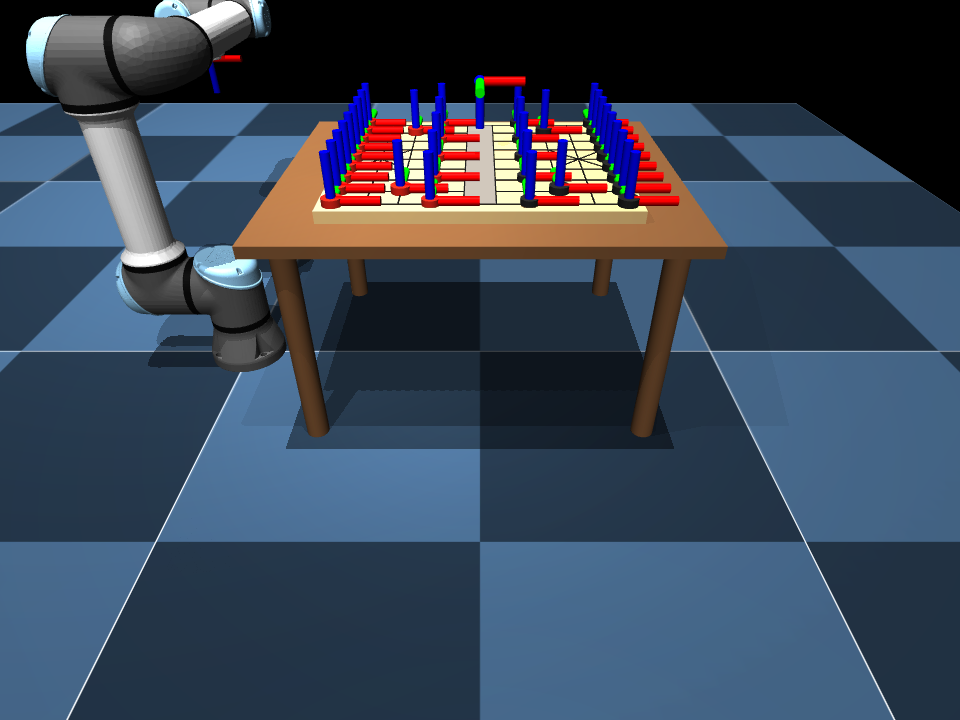

In [32]:
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, "home_xiangqi")
mujoco.mj_resetDataKeyframe(model, data, key_id)

renderer = mujoco.Renderer(model, width=960, height=720)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_SITE
scene_option.sitegroup[4] = 1

mujoco.mj_forward(model, data)

mocap_id = model.body("target").mocapid[0]
site_id = model.site("attachment_site").id
n_robot_joints = 6

renderer.update_scene(data, camera="top_view", scene_option=scene_option)
media.show_image(renderer.render())

renderer.update_scene(data, camera="side_view", scene_option=scene_option)
media.show_image(renderer.render())

## Define Chess Moves

In [33]:
BOARD_Z = 0.426

# UR5e shoulder is at z=0.163, max reach ~0.85m.
# Lift/approach heights must keep all waypoints within reach.
# Worst case: row 9 at x=0.725, y=±0.20.
#   dist(shoulder, (0.725, 0.20, 0.48)) = 0.815m  OK
#   dist(shoulder, (0.725, 0.20, 0.55)) = 0.846m  EDGE → singularity!
LIFT_Z = 0.48
APPROACH_Z = 0.46

def board_pos(row, col):
    """Convert board row/col to world x,y,z coordinates."""
    x = 0.275 + row * 0.05
    y = -0.20 + col * 0.05
    return np.array([x, y, BOARD_Z])

def generate_move_waypoints(from_row, from_col, to_row, to_col, hover_time=0.5, move_time=1.0):
    """Generate waypoint sequence for a chess move (pick and place)."""
    start = board_pos(from_row, from_col)
    end = board_pos(to_row, to_col)

    waypoints = [
        (np.array([start[0], start[1], APPROACH_Z]), hover_time),
        (np.array([start[0], start[1], BOARD_Z + 0.01]), hover_time),
        (np.array([start[0], start[1], LIFT_Z]), hover_time),
        (np.array([end[0], end[1], LIFT_Z]), move_time),
        (np.array([end[0], end[1], BOARD_Z + 0.01]), hover_time),
        (np.array([end[0], end[1], APPROACH_Z]), hover_time),
    ]
    return waypoints

# Common Xiangqi opening moves
# Format: (from_row, from_col, to_row, to_col, piece_name)
chess_moves = [
    (2, 1, 2, 4, "red_cannon_1"),
    (9, 1, 7, 2, "black_horse_1"),
    (0, 1, 2, 2, "red_horse_1"),
    (9, 0, 9, 1, "black_chariot_1"),
]

## IK Controller and Simulation

In [34]:
framerate = 30

settle_duration = 1.0

jac = np.zeros((6, model.nv))
error = np.zeros(6)
error_pos = error[:3]
error_ori = error[3:]
site_quat = np.zeros(4)
site_quat_conj = np.zeros(4)
error_quat = np.zeros(4)

target_quat = np.array([0, 1, 0, 0], dtype=np.float64)

home_pos = np.array([0.4, 0, LIFT_Z])
all_waypoints = []
waypoint_actions = {}

for move in chess_moves:
    from_r, from_c, to_r, to_c, piece_name = move

    all_waypoints.append((home_pos.copy(), 1.0))

    move_start_idx = len(all_waypoints)
    move_waypoints = generate_move_waypoints(from_r, from_c, to_r, to_c)
    all_waypoints.extend(move_waypoints)

    # Trigger suction right after arriving above source piece, release above destination.
    waypoint_actions[move_start_idx + 1] = ("attach", piece_name)
    waypoint_actions[move_start_idx + 4] = ("detach", piece_name)

all_waypoints.append((home_pos.copy(), 1.0))

piece_joint_state = {}
for _, _, _, _, piece_name in chess_moves:
    joint_name = f"{piece_name}_jnt"
    joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
    if joint_id < 0:
        raise ValueError(f"Could not find freejoint '{joint_name}'")
    piece_joint_state[piece_name] = (
        model.jnt_qposadr[joint_id],
        model.jnt_dofadr[joint_id],
    )


def apply_suction_pose(piece_name, z_offset=0.0105):
    qpos_adr, dof_adr = piece_joint_state[piece_name]

    ee_pos = data.site(site_id).xpos.copy()
    ee_mat = data.site(site_id).xmat.reshape(3, 3)

    # Keep piece center slightly below the tool centerline while attached.
    piece_pos = ee_pos - ee_mat[:, 2] * z_offset

    data.qpos[qpos_adr : qpos_adr + 3] = piece_pos
    data.qpos[qpos_adr + 3 : qpos_adr + 7] = np.array([1.0, 0.0, 0.0, 0.0])
    data.qvel[dof_adr : dof_adr + 6] = 0.0


def run_rollout(camera_name, record_diagnostics=False):
    mujoco.mj_resetDataKeyframe(model, data, key_id)
    mujoco.mj_forward(model, data)

    data.ctrl[:] = data.qpos[:n_robot_joints]
    while data.time < settle_duration:
        mujoco.mj_step(model, data)

    frames = []
    current_wp_idx = 0
    wp_start_time = data.time
    sim_start_time = data.time
    current_target = all_waypoints[0][0].copy()

    data.mocap_pos[mocap_id] = current_target
    data.mocap_quat[mocap_id] = target_quat

    attached_piece = None
    total_duration = data.time + sum(wp[1] for wp in all_waypoints) + 2.0

    # --- IK controller parameters ---
    q_home = np.array([-1.5708, -1.5708, 1.5708, -1.5708, -1.5708, 0])
    N_IK_ITERS = 5
    damping_base = 1e-5
    damping_singular = 5e-3
    sv_thresh = 0.05
    k_null = 0.5
    max_dq_ik = 0.3
    kd_over_kp = 0.2        # Kd/Kp ratio for velocity feedforward
    eye6 = np.eye(n_robot_joints)
    # Future: an RL residual policy (SAC/PPO via stable-baselines3) on top of
    # this IK controller could further improve adaptive tracking.

    diag_time, diag_q, diag_ee, diag_tgt, diag_err = [], [], [], [], []
    step_count = 0

    jac_ik = np.zeros((6, model.nv))
    sq = np.zeros(4)
    sqc = np.zeros(4)
    eq = np.zeros(4)
    eo = np.zeros(3)

    while data.time < total_duration and current_wp_idx < len(all_waypoints):
        wp_pos, wp_dur = all_waypoints[current_wp_idx]

        t_frac = min(1.0, (data.time - wp_start_time) / max(wp_dur, 0.01))
        data.mocap_pos[mocap_id] = current_target + (wp_pos - current_target) * t_frac
        data.mocap_quat[mocap_id] = target_quat

        if data.time - wp_start_time >= wp_dur:
            action = waypoint_actions.get(current_wp_idx)
            if action is not None:
                action_type, piece_name = action
                if action_type == "attach":
                    attached_piece = piece_name
                    apply_suction_pose(attached_piece)
                    mujoco.mj_forward(model, data)
                elif action_type == "detach" and attached_piece == piece_name:
                    qpos_adr, dof_adr = piece_joint_state[piece_name]
                    ee_pos = data.site(site_id).xpos.copy()
                    data.qpos[qpos_adr:qpos_adr + 3] = [ee_pos[0], ee_pos[1], BOARD_Z]
                    data.qpos[qpos_adr + 3:qpos_adr + 7] = [1.0, 0.0, 0.0, 0.0]
                    data.qvel[dof_adr:dof_adr + 6] = 0.0
                    mujoco.mj_forward(model, data)
                    attached_piece = None

            current_target = wp_pos.copy()
            current_wp_idx += 1
            wp_start_time = data.time
            if current_wp_idx >= len(all_waypoints):
                break

        tgt_p = data.mocap_pos[mocap_id].copy()
        tgt_q = data.mocap_quat[mocap_id].copy()
        q_actual = data.qpos[:n_robot_joints].copy()
        q_ik = q_actual.copy()
        lam = damping_base

        for ik_it in range(N_IK_ITERS):
            data.qpos[:n_robot_joints] = q_ik
            mujoco.mj_kinematics(model, data)
            mujoco.mj_comPos(model, data)

            ep = tgt_p - data.site(site_id).xpos
            mujoco.mju_mat2Quat(sq, data.site(site_id).xmat)
            mujoco.mju_negQuat(sqc, sq)
            mujoco.mju_mulQuat(eq, tgt_q, sqc)
            mujoco.mju_quat2Vel(eo, eq, 1.0)

            if np.linalg.norm(ep) < 5e-5 and np.linalg.norm(eo) < 1e-4:
                break

            mujoco.mj_jacSite(model, data, jac_ik[:3], jac_ik[3:], site_id)
            Jr = jac_ik[:, :n_robot_joints]

            if ik_it == 0:
                sv_min = np.linalg.svd(Jr, compute_uv=False)[-1]
                lam = damping_base + max(0.0, 1.0 - sv_min / sv_thresh) ** 2 * damping_singular

            te = np.concatenate((ep, eo))
            lhs = Jr.T @ Jr + lam * eye6
            dq = np.linalg.solve(lhs, Jr.T @ te)

            J_pinv = np.linalg.solve(lhs, Jr.T)
            dq += (eye6 - J_pinv @ Jr) @ (k_null * (q_home - q_ik))

            dq = np.clip(dq, -max_dq_ik, max_dq_ik)
            q_ik += dq
            for i in range(n_robot_joints):
                lo, hi = model.jnt_range[i]
                q_ik[i] = np.clip(q_ik[i], lo, hi)

        data.qpos[:n_robot_joints] = q_actual
        mujoco.mj_kinematics(model, data)
        mujoco.mj_comPos(model, data)

        if t_frac < 1.0 and wp_dur > 0.01:
            v_cart = np.zeros(6)
            v_cart[:3] = (wp_pos - current_target) / wp_dur
            mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)
            Jr_a = jac[:, :n_robot_joints]
            lhs_ff = Jr_a.T @ Jr_a + damping_base * eye6
            qdot_des = np.linalg.solve(lhs_ff, Jr_a.T @ v_cart)
            q_cmd = q_ik + kd_over_kp * qdot_des
        else:
            q_cmd = q_ik

        error_pos[:] = tgt_p - data.site(site_id).xpos

        if attached_piece is not None:
            apply_suction_pose(attached_piece)

        data.ctrl[:n_robot_joints] = q_cmd
        mujoco.mj_step(model, data)

        if record_diagnostics and step_count % 20 == 0:
            diag_time.append(data.time)
            diag_q.append(data.qpos[:n_robot_joints].copy())
            diag_ee.append(data.site(site_id).xpos.copy())
            diag_tgt.append(data.mocap_pos[mocap_id].copy())
            diag_err.append(np.linalg.norm(error_pos))
        step_count += 1

        if len(frames) < (data.time - sim_start_time) * framerate:
            renderer.update_scene(data, camera=camera_name, scene_option=scene_option)
            frames.append(renderer.render())

    if record_diagnostics:
        diag = {
            "time": np.array(diag_time),
            "q": np.array(diag_q),
            "ee_pos": np.array(diag_ee),
            "target_pos": np.array(diag_tgt),
            "ik_error": np.array(diag_err),
        }
        return frames, diag
    return frames

frames, diagnostics = run_rollout("side_view", record_diagnostics=True)
print(f"Recorded {len(frames)} frames")
media.show_video(frames, fps=framerate)

Recorded 571 frames


This browser does not support the video tag.


## Top View

In [35]:
frames_top = run_rollout("top_view")

print(f"Recorded {len(frames_top)} frames (top view)")
media.show_video(frames_top, fps=framerate)

Recorded 571 frames (top view)


This browser does not support the video tag.


## Joint Diagnostics

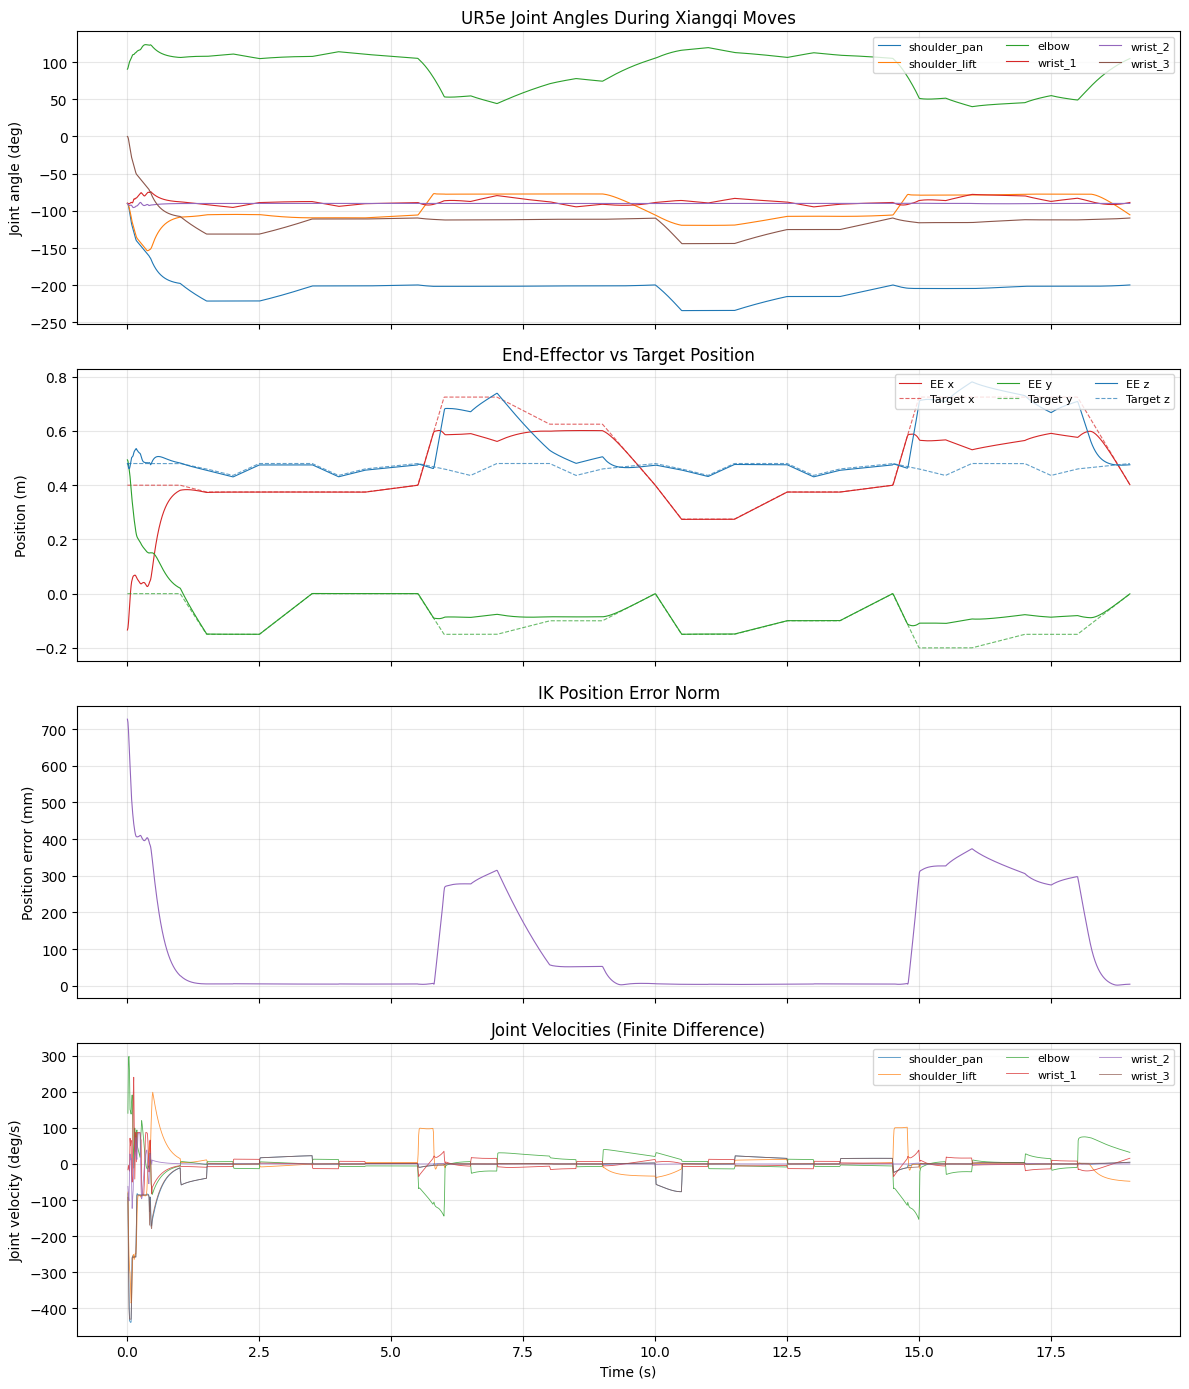

Max IK error: 727.10 mm
Mean IK error: 102.40 mm
Total diagnostics samples: 1901


In [36]:
import matplotlib.pyplot as plt

joint_names = [
    "shoulder_pan", "shoulder_lift", "elbow",
    "wrist_1", "wrist_2", "wrist_3",
]
t = diagnostics["time"] - diagnostics["time"][0]

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# --- Joint angles ---
ax = axes[0]
for j in range(6):
    ax.plot(t, np.degrees(diagnostics["q"][:, j]), label=joint_names[j], linewidth=0.8)
ax.set_ylabel("Joint angle (deg)")
ax.set_title("UR5e Joint Angles During Xiangqi Moves")
ax.legend(loc="upper right", fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

# --- End-effector position vs target ---
ax = axes[1]
labels_xyz = ["x", "y", "z"]
colors = ["tab:red", "tab:green", "tab:blue"]
for k in range(3):
    ax.plot(t, diagnostics["ee_pos"][:, k], color=colors[k],
            label=f"EE {labels_xyz[k]}", linewidth=0.8)
    ax.plot(t, diagnostics["target_pos"][:, k], color=colors[k],
            linestyle="--", label=f"Target {labels_xyz[k]}", linewidth=0.8, alpha=0.7)
ax.set_ylabel("Position (m)")
ax.set_title("End-Effector vs Target Position")
ax.legend(loc="upper right", fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

# --- IK position error norm ---
ax = axes[2]
ax.plot(t, diagnostics["ik_error"] * 1000, color="tab:purple", linewidth=0.8)
ax.set_ylabel("Position error (mm)")
ax.set_title("IK Position Error Norm")
ax.grid(True, alpha=0.3)

# --- Joint velocities (finite difference) ---
ax = axes[3]
dt_diag = np.diff(t)
for j in range(6):
    dq_dt = np.diff(diagnostics["q"][:, j]) / dt_diag
    ax.plot(t[1:], np.degrees(dq_dt), label=joint_names[j], linewidth=0.6, alpha=0.8)
ax.set_ylabel("Joint velocity (deg/s)")
ax.set_xlabel("Time (s)")
ax.set_title("Joint Velocities (Finite Difference)")
ax.legend(loc="upper right", fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("xiangqi_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Max IK error: {diagnostics['ik_error'].max()*1000:.2f} mm")
print(f"Mean IK error: {diagnostics['ik_error'].mean()*1000:.2f} mm")
print(f"Total diagnostics samples: {len(t)}")